# **Situação Negócio**

Atuaremos como cientistas de dados de uma grande **concessionária de veículos** que vende automóveis usados. A concessionária enfrenta alguns problemas para precificar esses automóveis usados. A precificação está atrelada a diversos fatores, como:

* O ano de fabricação do veículo;
* A quilometragem;
* A marca;
* O modelo;
* Entre outros.

Para facilitar esse processo de precificação, a ideia é criar um modelo de Machine Learning capaz de prever os valores dos automóveis com base nas características que eles possuem.

Para isso, utilizaremos uma biblioteca muito especial em Machine Learning: a biblioteca XGBoost, muito utilizada em competições de Machine Learning e costuma apresentar resultados bem interessantes.

# **Base de Dados**

In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/alura-cursos/regressao_boosting/refs/heads/main/Dados/dados_automoveis.csv'

In [3]:
df = pd.read_csv(url)
df.head()

,Marca,Modelo,Ano,Tipo_combustivel,Potencia_motor,Cilindros_motor,Tipo_transmissao,Rodas_motrizes,Numero_portas,Tamanho,Estilo,Consumo_estrada_milhas,Consumo_cidade_milhas,Valor($)
0,GMC,Envoy XL,2005,gasolina comum,275.0,6.0,automatico,tracao traseira,4.0,grande,SUV 4 portas,18,13,29695
1,Volkswagen,Passat,2016,gasolina comum,170.0,4.0,automatico,tracao dianteira,4.0,medio,seda,38,25,30495
2,Honda,Odyssey,2016,gasolina comum,248.0,6.0,automatico,tracao dianteira,4.0,grande,minivan de passageiros,28,19,37650
3,Chevrolet,Cruze,2015,gasolina comum,138.0,4.0,manual,tracao dianteira,4.0,medio,seda,36,25,16170
4,Volvo,740,1991,gasolina comum,162.0,4.0,automatico,tracao traseira,4.0,medio,seda,20,17,2000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10918 entries, 0 to 10917
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Marca                   10918 non-null  object 
 1   Modelo                  10918 non-null  object 
 2   Ano                     10918 non-null  int64  
 3   Tipo_combustivel        10918 non-null  object 
 4   Potencia_motor          10862 non-null  float64
 5   Cilindros_motor         10888 non-null  float64
 6   Tipo_transmissao        10918 non-null  object 
 7   Rodas_motrizes          10918 non-null  object 
 8   Numero_portas           10916 non-null  float64
 9   Tamanho                 10918 non-null  object 
 10  Estilo                  10918 non-null  object 
 11  Consumo_estrada_milhas  10918 non-null  int64  
 12  Consumo_cidade_milhas   10918 non-null  int64  
 13  Valor($)                10918 non-null  int64  
dtypes: float64(3), int64(4), object(7)
mem

# **EDA**

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ano,10918.0,2010.104323,7.768498,1990.0,2006.0,2014.0,2016.00,2017.0
Potencia_motor,10862.0,227.939882,80.902635,55.0,168.0,210.0,285.00,707.0
Cilindros_motor,10888.0,5.357366,1.450271,0.0,4.0,6.0,6.00,12.0
Numero_portas,10916.0,3.489648,0.850956,2.0,3.0,4.0,4.00,4.0
Consumo_estrada_milhas,10918.0,27.069243,8.651855,12.0,22.0,26.0,31.00,354.0
Consumo_cidade_milhas,10918.0,20.159828,8.814101,10.0,16.0,19.0,22.00,137.0
Valor($),10918.0,28671.733284,15944.446640,2000.0,20095.0,28472.5,38198.75,74000.0


Insigths:

* Ano --> Minimo é do ano de 1990 e máximo de 2017 (ok)
* Consumo estrada --> Minimo 12 e máximo de 354 (Possivel outilers)  
* Consumo cidade --> Minimo 10 e máximo de 137 (Possivel outilers)


# **Data Cleaning**

In [6]:
df_limpo = df.copy()

## **Dados Nulos**

In [7]:
df_limpo.isnull().sum()

,0
Marca,0
Modelo,0
Ano,0
Tipo_combustivel,0
Potencia_motor,56
Cilindros_motor,30
Tipo_transmissao,0
Rodas_motrizes,0
Numero_portas,2
Tamanho,0


In [8]:
df_limpo = df_limpo.dropna()

In [9]:
df_limpo.isnull().sum()

,0
Marca,0
Modelo,0
Ano,0
Tipo_combustivel,0
Potencia_motor,0
Cilindros_motor,0
Tipo_transmissao,0
Rodas_motrizes,0
Numero_portas,0
Tamanho,0


## **Dados Duplicados**

In [10]:
df_limpo.duplicated().sum()

np.int64(709)

In [11]:
df_limpo = df_limpo.drop_duplicates()
df_limpo.duplicated().sum()

np.int64(0)

In [12]:
df_limpo = df_limpo.reset_index(drop=True)

In [13]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10124 entries, 0 to 10123
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Marca                   10124 non-null  object 
 1   Modelo                  10124 non-null  object 
 2   Ano                     10124 non-null  int64  
 3   Tipo_combustivel        10124 non-null  object 
 4   Potencia_motor          10124 non-null  float64
 5   Cilindros_motor         10124 non-null  float64
 6   Tipo_transmissao        10124 non-null  object 
 7   Rodas_motrizes          10124 non-null  object 
 8   Numero_portas           10124 non-null  float64
 9   Tamanho                 10124 non-null  object 
 10  Estilo                  10124 non-null  object 
 11  Consumo_estrada_milhas  10124 non-null  int64  
 12  Consumo_cidade_milhas   10124 non-null  int64  
 13  Valor($)                10124 non-null  int64  
dtypes: float64(3), int64(4), object(7)
mem

## **Outiliers**

In [14]:
df_limpo.describe().T

,count,mean,std,min,25%,50%,75%,max
Ano,10124.0,2010.430956,7.428468,1990.0,2007.0,2015.0,2016.0,2017.0
Potencia_motor,10124.0,231.208613,81.594637,55.0,170.0,220.0,287.0,707.0
Cilindros_motor,10124.0,5.398558,1.431391,0.0,4.0,6.0,6.0,12.0
Numero_portas,10124.0,3.509482,0.839841,2.0,3.0,4.0,4.0,4.0
Consumo_estrada_milhas,10124.0,26.789905,7.536930,12.0,22.0,26.0,31.0,354.0
Consumo_cidade_milhas,10124.0,19.806401,6.637616,10.0,16.0,19.0,22.0,137.0
Valor($),10124.0,29356.918807,15772.123413,2000.0,20575.0,29062.5,38900.0,74000.0


In [15]:
def remover_outliers(df, coluna):
    # Calcula o primeiro e o terceiro quartil
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)

    # Calcula o Intervalo Interquartil (IQR)
    iqr = q3 - q1

    # Define os limites para o que é considerado outlier
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Filtra o DataFrame mantendo apenas os valores dentro dos limites
    df_filtrado = df[(df[coluna] >= limite_inferior) & (df[coluna] <= limite_superior)]

    return df_filtrado

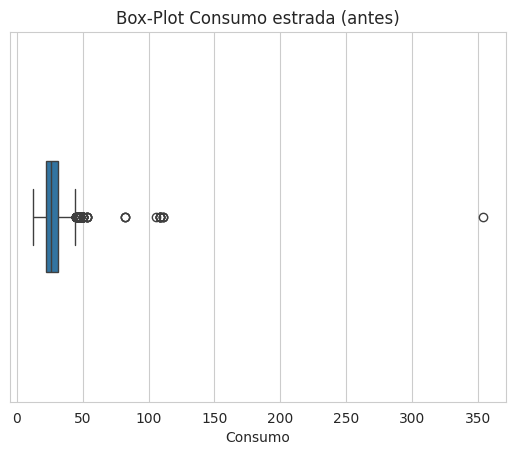

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
sns.boxplot(df_limpo['Consumo_estrada_milhas'], orient='h', width=0.3)
plt.title('Box-Plot Consumo estrada (antes)')
plt.xlabel('Consumo')
plt.show()

In [17]:
df_limpo = remover_outliers(df_limpo, 'Consumo_estrada_milhas')

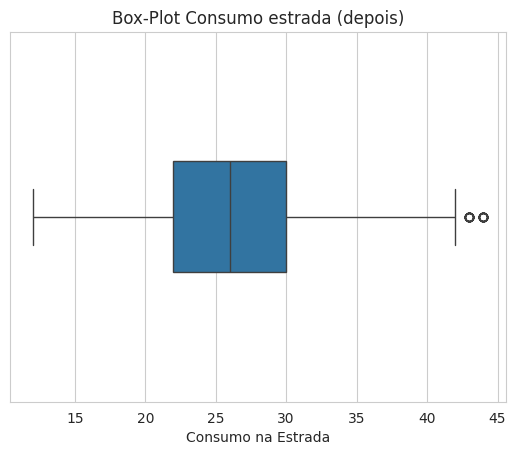

In [18]:
sns.set_style('whitegrid')
sns.boxplot(df_limpo['Consumo_estrada_milhas'], orient='h', width=0.3)
plt.title('Box-Plot Consumo estrada (depois)')
plt.xlabel('Consumo na Estrada')
plt.show()

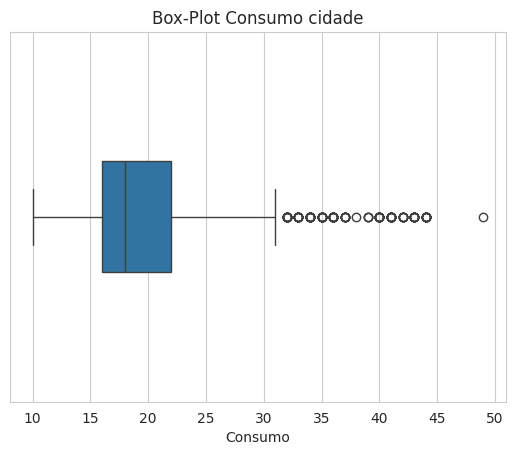

In [19]:
sns.set_style('whitegrid')
sns.boxplot(df_limpo['Consumo_cidade_milhas'], orient='h', width=0.3)
plt.title('Box-Plot Consumo cidade')
plt.xlabel('Consumo')
plt.show()

In [20]:
df_limpo = remover_outliers(df_limpo, 'Consumo_cidade_milhas')

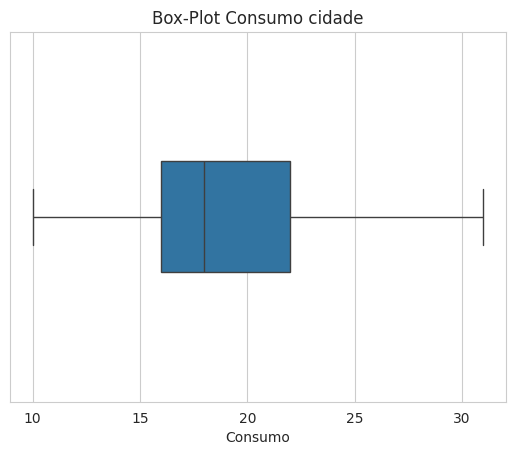

In [21]:
remover_outliers(df_limpo, 'Consumo_cidade_milhas')

sns.set_style('whitegrid')
sns.boxplot(df_limpo['Consumo_cidade_milhas'], orient='h', width=0.3)
plt.title('Box-Plot Consumo cidade')
plt.xlabel('Consumo')
plt.show()

## **Conversão dos tipo de dados**

In [22]:
df_ml = df_limpo.copy()

In [23]:
colunas_categoricas = df_ml.select_dtypes('object').columns
colunas_categoricas

Index(['Marca', 'Modelo', 'Tipo_combustivel', 'Tipo_transmissao',
       'Rodas_motrizes', 'Tamanho', 'Estilo'],
      dtype='object')

In [24]:
df_ml[colunas_categoricas] = df_ml[colunas_categoricas].astype('category')

In [25]:
print(df_ml.dtypes)

Marca                     category
Modelo                    category
Ano                          int64
Tipo_combustivel          category
Potencia_motor             float64
Cilindros_motor            float64
Tipo_transmissao          category
Rodas_motrizes            category
Numero_portas              float64
Tamanho                   category
Estilo                    category
Consumo_estrada_milhas       int64
Consumo_cidade_milhas        int64
Valor($)                     int64
dtype: object


# **Data Engineering**

## **Conversão para Real**

In [26]:
kms_conversao = (1.60934 / 3.78541)
cambio_dolar = 5.22      # (7/02/2026)

df_conversao = df_limpo.copy()
df_conversao['Consumo_estrada_km'] = (df_conversao['Consumo_estrada_milhas'] * kms_conversao).round(2)
df_conversao['Consumo_cidade_km'] = (df_conversao['Consumo_cidade_milhas'] * kms_conversao).round(2)
df_conversao['Valor(R$)'] = (df_conversao['Valor($)'] * cambio_dolar).round(2)
df_conversao.head()

,Marca,Modelo,Ano,Tipo_combustivel,Potencia_motor,Cilindros_motor,Tipo_transmissao,Rodas_motrizes,Numero_portas,Tamanho,Estilo,Consumo_estrada_milhas,Consumo_cidade_milhas,Valor($),Consumo_estrada_km,Consumo_cidade_km,Valor(R$)
0,GMC,Envoy XL,2005,gasolina comum,275.0,6.0,automatico,tracao traseira,4.0,grande,SUV 4 portas,18,13,29695,7.65,5.53,155007.9
1,Volkswagen,Passat,2016,gasolina comum,170.0,4.0,automatico,tracao dianteira,4.0,medio,seda,38,25,30495,16.16,10.63,159183.9
2,Honda,Odyssey,2016,gasolina comum,248.0,6.0,automatico,tracao dianteira,4.0,grande,minivan de passageiros,28,19,37650,11.90,8.08,196533.0
3,Chevrolet,Cruze,2015,gasolina comum,138.0,4.0,manual,tracao dianteira,4.0,medio,seda,36,25,16170,15.31,10.63,84407.4
4,Volvo,740,1991,gasolina comum,162.0,4.0,automatico,tracao traseira,4.0,medio,seda,20,17,2000,8.50,7.23,10440.0


# **Machine Learning**

In [27]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9865 entries, 0 to 10123
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Marca                   9865 non-null   category
 1   Modelo                  9865 non-null   category
 2   Ano                     9865 non-null   int64   
 3   Tipo_combustivel        9865 non-null   category
 4   Potencia_motor          9865 non-null   float64 
 5   Cilindros_motor         9865 non-null   float64 
 6   Tipo_transmissao        9865 non-null   category
 7   Rodas_motrizes          9865 non-null   category
 8   Numero_portas           9865 non-null   float64 
 9   Tamanho                 9865 non-null   category
 10  Estilo                  9865 non-null   category
 11  Consumo_estrada_milhas  9865 non-null   int64   
 12  Consumo_cidade_milhas   9865 non-null   int64   
 13  Valor($)                9865 non-null   int64   
dtypes: category(7), float64(3), 

## **Divisão da Base de Dados**

In [28]:
X = df_ml.drop('Valor($)', axis=1)
y = df_ml['Valor($)']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4256)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7892, 13), (1973, 13), (7892,), (1973,))

## **Modelo Xgboost**

In [30]:
import xgboost as xgb

modelo_xgboost = xgb.XGBRegressor(objective ='reg:squarederror', enable_categorical=True, n_estimators=100)

modelo_xgboost.fit(X_train, y_train)

y_pred_xgboost = modelo_xgboost.predict(X_test)

### **Avaliação do Modelo**

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def get_metrics(y_test, y_pred):
    mae = (mean_absolute_error(y_test, y_pred))
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return mae, mse, rmse, r2

def get_format(num):
    return f'{num:,.2f}'.replace('.','X').replace(',','.').replace('X',',')

mae, mse, rmse, r2 = get_metrics(y_test, y_pred_xgboost)
print(f'MAE: {get_format(mae)}')
print(f'MSE: {get_format(mse)}')
print(f'RMSE: {get_format(rmse)}')
print(f'R2: {r2:.4f}')

MAE: 2.195,38
MSE: 11.101.565,00
RMSE: 3.331,90
R2: 0.9516


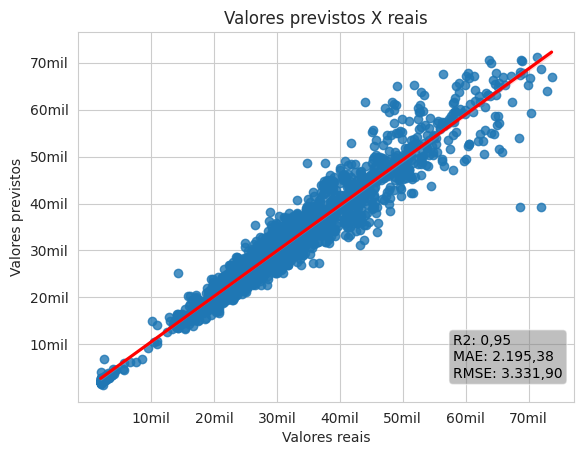

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(x=y_test, y=y_pred_xgboost, line_kws={'color':'red'})
plt.xlabel('Valores reais')
plt.ylabel('Valores previstos')
plt.title('Valores previstos X reais')

tick_locations = [x for x in range(int(10e3), int(80e3), int(10e3))]
tick_labels = [f'{x // 1000}mil' for x in tick_locations]
plt.xticks(tick_locations, tick_labels)
plt.yticks(tick_locations, tick_labels)
plt.text(58000, 3000, s=f'R2: {get_format(r2)}\nMAE: {get_format(mae)}\nRMSE: {get_format(rmse)}', color='black',
         bbox=dict(facecolor='gray', alpha=0.5, boxstyle='round'))
plt.show()

## **XGBoost Nativo**

### **Divisão em treino e teste**

In [33]:
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

### **Treinando**

In [34]:
params = {
    'objective': 'reg:squarederror'
}

model = xgb.train(
    params = params,
    dtrain = dtrain,
    num_boost_round=100
)

In [35]:
y_pred_x = model.predict(dtest)

In [36]:
y_pred_x

array([18992.574, 29669.543, 66740.63 , ..., 50229.89 , 50043.113,
       34390.58 ], dtype=float32)

In [37]:
dtest.get_label()

array([20035., 29145., 60450., ..., 45750., 50360., 32715.], dtype=float32)

### **Avaliação**

In [38]:
mae, mse, rmse, r2 = get_metrics(dtest.get_label(), y_pred_x)

print(f'MAE: {get_format(mae)}')
print(f'MSE: {get_format(mse)}')
print(f'RMSE: {get_format(rmse)}')
print(f'R2: {r2:.4f}')

MAE: 2.195,38
MSE: 11.101.565,00
RMSE: 3.331,90
R2: 0.9516


### **Features mais Importantes**

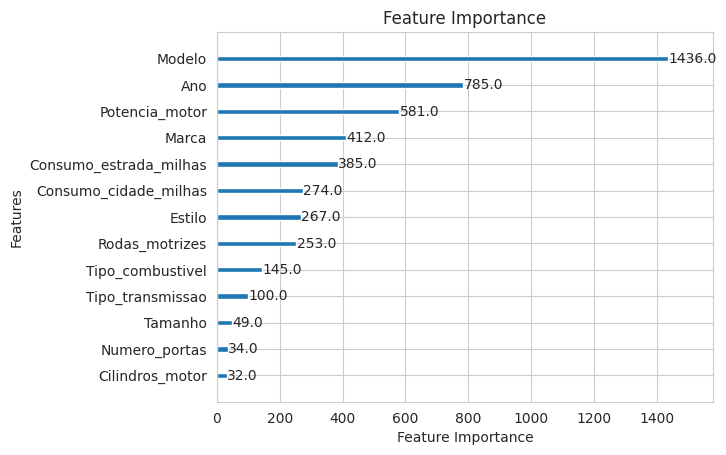

In [39]:
## Features mais importantes

xgb.plot_importance(model)
plt.title('Feature Importance')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.show()

In [40]:
#Validacao Cruzada
params = {'objective': 'reg:squarederror'}
n = 100
evals = [(dtrain, 'train'), (dtest, 'test')]

model_cv = xgb.train(
    params = params,
    dtrain = dtrain,
    num_boost_round=n,
    evals=evals
)

[0]	train-rmse:11618.53333	test-rmse:11043.04824
[1]	train-rmse:8573.73226	test-rmse:8289.70998
[2]	train-rmse:6528.30154	test-rmse:6459.14774
[3]	train-rmse:5101.69320	test-rmse:5210.17978
[4]	train-rmse:4181.50218	test-rmse:4421.47141
[5]	train-rmse:3605.82494	test-rmse:3969.92570
[6]	train-rmse:3192.75374	test-rmse:3639.81299
[7]	train-rmse:2951.28123	test-rmse:3453.53405
[8]	train-rmse:2772.31872	test-rmse:3334.89921
[9]	train-rmse:2653.91893	test-rmse:3253.92540
[10]	train-rmse:2565.95884	test-rmse:3213.69642
[11]	train-rmse:2504.59119	test-rmse:3186.99283
[12]	train-rmse:2465.16632	test-rmse:3180.15583
[13]	train-rmse:2434.86918	test-rmse:3189.43941
[14]	train-rmse:2404.29794	test-rmse:3198.49935
[15]	train-rmse:2385.23925	test-rmse:3198.14690
[16]	train-rmse:2363.77848	test-rmse:3192.51718
[17]	train-rmse:2342.71720	test-rmse:3204.66444
[18]	train-rmse:2329.39774	test-rmse:3210.50990
[19]	train-rmse:2320.89567	test-rmse:3208.85578
[20]	train-rmse:2311.08164	test-rmse:3206.66675


In [41]:
model_cv.get_score()

{'Marca': 412.0,
 'Modelo': 1436.0,
 'Ano': 785.0,
 'Tipo_combustivel': 145.0,
 'Potencia_motor': 581.0,
 'Cilindros_motor': 32.0,
 'Tipo_transmissao': 100.0,
 'Rodas_motrizes': 253.0,
 'Numero_portas': 34.0,
 'Tamanho': 49.0,
 'Estilo': 267.0,
 'Consumo_estrada_milhas': 385.0,
 'Consumo_cidade_milhas': 274.0}

In [42]:
params = {'objective': 'reg:squarederror'}
n = 100
evals = [(dtrain, 'train'), (dtest, 'test')]

model = xgb.train(
    params = params,
    dtrain = dtrain,
    num_boost_round=n,
    evals=evals,              # Treino e teste
    verbose_eval=10,          # Mostra o resultado de 10 em 10
    early_stopping_rounds=10  # Para quando não houver mais melhora
)

[0]	train-rmse:11618.53333	test-rmse:11043.04824
[10]	train-rmse:2565.95884	test-rmse:3213.69642
[20]	train-rmse:2311.08164	test-rmse:3206.66675
[22]	train-rmse:2291.90520	test-rmse:3211.14683


### **Validação Cruzada**

In [43]:
params = {'objective': 'reg:squarederror'}

cv_resultados = xgb.cv(dtrain=dtrain,
                       params=params,
                       nfold=5,
                       num_boost_round=1000,
                       early_stopping_rounds=10,
                       metrics='rmse',
                       as_pandas=True,
                       seed=4789)

cv_resultados

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,11615.459580,63.445986,11747.576684,308.291992
1,8553.510856,47.465393,8797.169381,273.114970
2,6496.660535,32.510686,6851.714864,243.353469
3,5080.002480,21.145878,5546.311363,230.385224
4,4166.167342,26.811726,4734.576552,184.722311
5,3556.393159,5.989954,4203.909377,190.005049
6,3167.353667,12.194375,3882.316012,185.837548
7,2906.963711,13.741061,3674.860870,173.233177
8,2736.686662,15.329241,3558.613385,162.673866
9,2606.265660,18.125795,3461.321640,163.229869


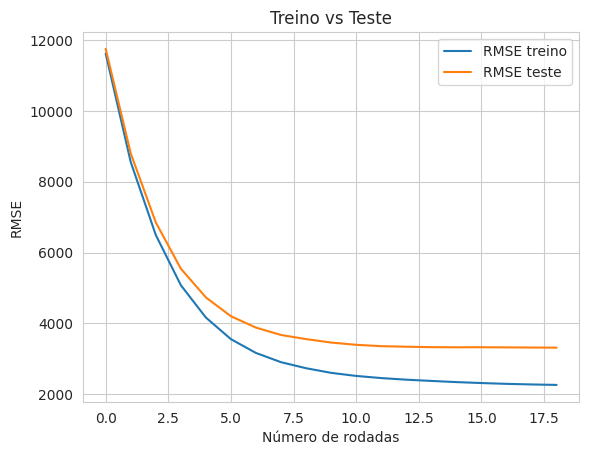

In [44]:
iteracoes = range(len(cv_resultados))

plt.plot(iteracoes, cv_resultados['train-rmse-mean'], label='RMSE treino')
plt.plot(iteracoes, cv_resultados['test-rmse-mean'], label='RMSE teste')
plt.title('Treino vs Teste')
plt.xlabel('Número de rodadas')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [45]:
list(range(len(cv_resultados)))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

### **Hiperparametros**

In [46]:
from sklearn.model_selection import GridSearchCV

params = {
    'colsample_bytree': [0.6, 1.0],
    'subsample': [0.5, 0.8, 1.0],
    'max_depth': [3, 5, 7, 10],
    #'eta': [0.01, 0.05, 0.1],
}

gbm = xgb.XGBRegressor(objective='reg:squarederror', enable_categorical=True)

grid_search = GridSearchCV(
    estimator=gbm,
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
{'colsample_bytree': 0.6, 'max_depth': 3, 'subsample': 1.0}


In [47]:
print('Resultados:')
print('---'*30)
print(f'Melhores hiperparametros: {grid_search.best_params_}')
print(f'Menor RMSE encontrado: {np.sqrt(np.abs(grid_search.best_score_))}')
print('---'*30)

Resultados:
------------------------------------------------------------------------------------------
Melhores hiperparametros: {'colsample_bytree': 0.6, 'max_depth': 3, 'subsample': 1.0}
Menor RMSE encontrado: 2992.77423137797
------------------------------------------------------------------------------------------


#### **Nativa do XGBoost**

In [48]:
import itertools
import pandas as pd
import xgboost as xgb

params_grid = {
    'max_depth': [3, 5, 7],
    'eta': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

resultados = []

for max_depth, eta, subsample, colsample in itertools.product(
    params_grid['max_depth'],
    params_grid['eta'],
    params_grid['subsample'],
    params_grid['colsample_bytree']
):

    params = {
        'objective': 'reg:squarederror',
        'max_depth': max_depth,
        'eta': eta,
        'subsample': subsample,
        'colsample_bytree': colsample
    }

    cv = xgb.cv(
        params=params,
        dtrain=dtrain,
        nfold=5,
        num_boost_round=1000,
        early_stopping_rounds=20,
        metrics='rmse',
        seed=42,
        as_pandas=True
    )

    resultados.append({
        'max_depth': max_depth,
        'eta': eta,
        'subsample': subsample,
        'colsample_bytree': colsample,
        'best_round': len(cv),
        'rmse': cv['test-rmse-mean'].min()
    })

resultado_final = (
    pd.DataFrame(resultados)
      .sort_values('rmse')
      .reset_index(drop=True)
)

resultado_final.head()

,max_depth,eta,subsample,colsample_bytree,best_round,rmse
0,3,0.05,1.0,0.8,764,3081.913819
1,3,0.10,1.0,0.8,357,3088.912576
2,3,0.10,0.8,0.8,288,3098.925816
3,3,0.05,0.8,0.8,548,3111.836696
4,5,0.10,0.8,0.8,119,3150.312153


### **Melhor Taxa de Aprendizagem**

In [49]:
def grafico_taxa_aprendizagem(train_mse, test_mse, eta=params['eta']):
    plt.plot(train_mse, label='Treino')
    plt.plot(test_mse, label='Teste')
    plt.title(f'Treino vs Teste\nCom taxa de aprendizagem {eta}')
    plt.xlabel('Número de rodadas')
    plt.ylabel('RMSE')
    plt.legend()
    plt.text(x=len(train_mse)-1.5e1, y=train_mse[0]-1.5e3, s=f'Melhor desempenho:\n- Train: {np.abs(np.min(train_mse)):.2f}\n- Test: {np.abs(np.min(test_mse)):.2f}',
             bbox=dict(facecolor='gray', alpha=0.5, boxstyle='round', edgecolor='black'), fontsize=8)
    plt.show()

[0]	train-rmse:15968.72015	test-rmse:15040.57662
[100]	train-rmse:8178.99597	test-rmse:7818.00779
[200]	train-rmse:5001.55859	test-rmse:4981.55140
[300]	train-rmse:3750.52875	test-rmse:3909.24110
[400]	train-rmse:3241.87374	test-rmse:3504.46925
[500]	train-rmse:2997.82878	test-rmse:3328.05028
[600]	train-rmse:2856.94089	test-rmse:3227.88478
[700]	train-rmse:2775.24085	test-rmse:3171.67458
[800]	train-rmse:2715.81682	test-rmse:3131.43343
[900]	train-rmse:2672.01393	test-rmse:3104.93974
[999]	train-rmse:2640.62350	test-rmse:3085.81481


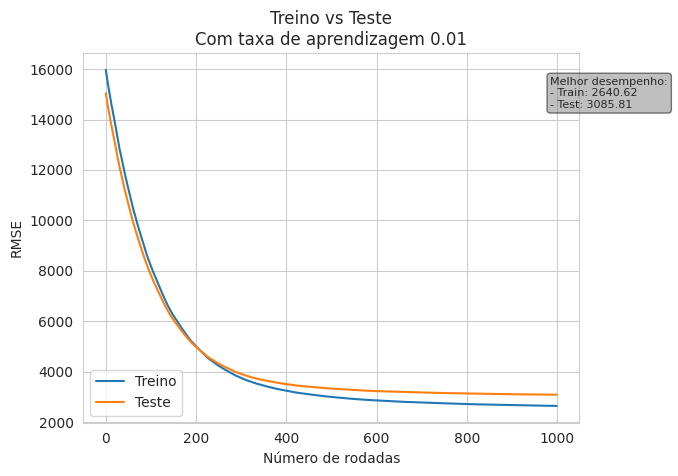

In [50]:
params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 0.6,
    'max_depth': 3,
    'subsample': 1.0,
    'eta': 0.01 ## Melhora a taxa de aprendizagem (melhor foi 0.3)
}

evals_result = {}

modelo = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    verbose_eval=100,
    evals_result=evals_result,
    early_stopping_rounds=50
)

train_mse = evals_result['train']['rmse']
test_mse = evals_result['test']['rmse']

grafico_taxa_aprendizagem(train_mse, test_mse, eta=params['eta'])

[0]	train-rmse:15842.09302	test-rmse:14921.76483
[100]	train-rmse:4987.49631	test-rmse:4962.66330
[200]	train-rmse:3239.36305	test-rmse:3504.31952
[300]	train-rmse:2858.04386	test-rmse:3225.96276
[400]	train-rmse:2721.33201	test-rmse:3137.57430
[500]	train-rmse:2643.56774	test-rmse:3093.28003
[600]	train-rmse:2590.95862	test-rmse:3061.56991
[700]	train-rmse:2547.92096	test-rmse:3044.56121
[800]	train-rmse:2514.85126	test-rmse:3026.24388
[900]	train-rmse:2486.78270	test-rmse:3014.78157
[999]	train-rmse:2467.15707	test-rmse:3008.68650


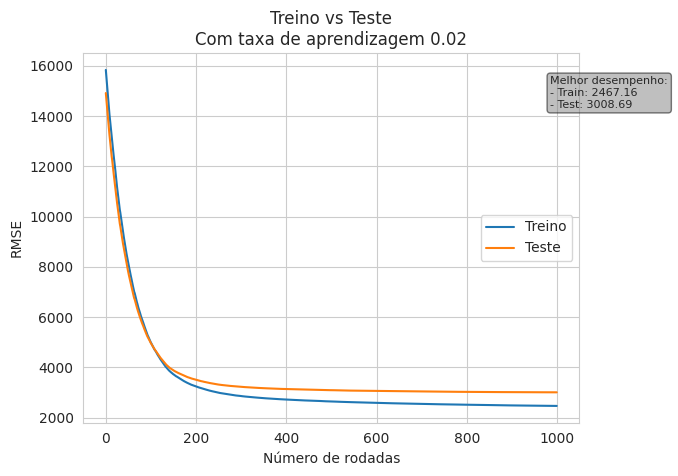

In [51]:
params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 0.6,
    'max_depth': 3,
    'subsample': 1.0,
    'eta': 0.02 ## Melhora a taxa de aprendizagem (melhor foi 0.3)
}

evals_result = {}

modelo = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    verbose_eval=100,
    evals_result=evals_result,
    early_stopping_rounds=50
)

train_mse = evals_result['train']['rmse']
test_mse = evals_result['test']['rmse']

grafico_taxa_aprendizagem(train_mse, test_mse, eta=params['eta'])

[0]	train-rmse:15463.91189	test-rmse:14567.18780
[100]	train-rmse:3040.41111	test-rmse:3355.65958
[200]	train-rmse:2663.88787	test-rmse:3123.78933
[300]	train-rmse:2540.20391	test-rmse:3047.59753
[400]	train-rmse:2470.50344	test-rmse:3015.77967
[500]	train-rmse:2425.64872	test-rmse:2990.22381
[600]	train-rmse:2390.24977	test-rmse:2969.40743
[700]	train-rmse:2361.92026	test-rmse:2952.42221
[800]	train-rmse:2339.37427	test-rmse:2939.99166
[900]	train-rmse:2322.28836	test-rmse:2931.76426
[999]	train-rmse:2307.08371	test-rmse:2928.36394


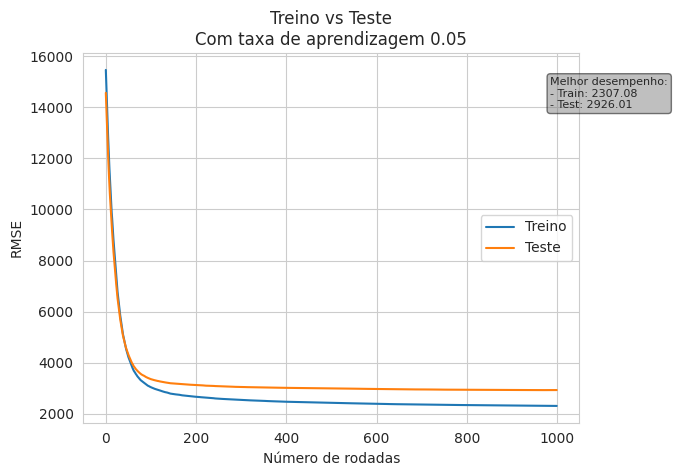

In [52]:
params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 0.6,
    'max_depth': 3,
    'subsample': 1.0,
    'eta': 0.05 ## Melhora a taxa de aprendizagem (melhor foi 0.3)
}

evals_result = {}

modelo = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    verbose_eval=100,
    evals_result=evals_result,
    early_stopping_rounds=50
)

train_mse = evals_result['train']['rmse']
test_mse = evals_result['test']['rmse']

grafico_taxa_aprendizagem(train_mse, test_mse, eta=params['eta'])

[0]	train-rmse:15338.44281	test-rmse:14449.64151
[100]	train-rmse:2878.70888	test-rmse:3241.42607
[200]	train-rmse:2592.79759	test-rmse:3090.90574
[300]	train-rmse:2492.29246	test-rmse:3029.74274
[400]	train-rmse:2427.49829	test-rmse:2991.98034
[500]	train-rmse:2389.16320	test-rmse:2977.47033
[600]	train-rmse:2356.40120	test-rmse:2958.07851
[700]	train-rmse:2334.86071	test-rmse:2949.83058
[800]	train-rmse:2315.02390	test-rmse:2941.01153
[900]	train-rmse:2296.58234	test-rmse:2933.96307
[999]	train-rmse:2280.25583	test-rmse:2932.48386


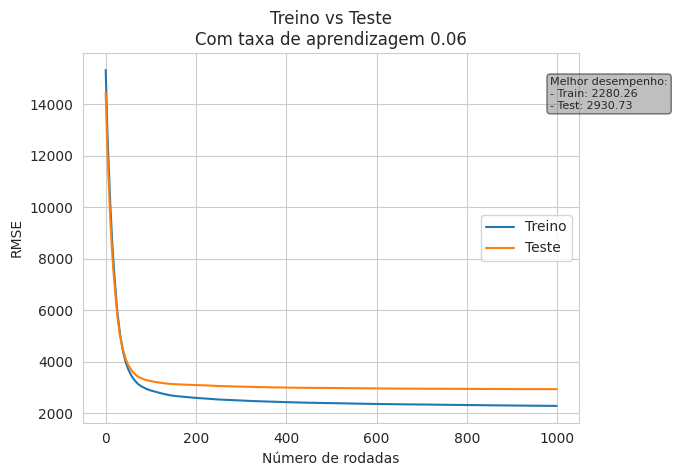

In [53]:
params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 0.6,
    'max_depth': 3,
    'subsample': 1.0,
    'eta': 0.06 ## Melhora a taxa de aprendizagem (melhor foi 0.3)
}

evals_result = {}

modelo = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    verbose_eval=100,
    evals_result=evals_result,
    early_stopping_rounds=50
)

train_mse = evals_result['train']['rmse']
test_mse = evals_result['test']['rmse']

grafico_taxa_aprendizagem(train_mse, test_mse, eta=params['eta'])

[0]	train-rmse:14839.71816	test-rmse:13982.89892
[100]	train-rmse:2671.83201	test-rmse:3141.13607
[200]	train-rmse:2462.89896	test-rmse:3023.25082
[284]	train-rmse:2387.29235	test-rmse:2985.94586


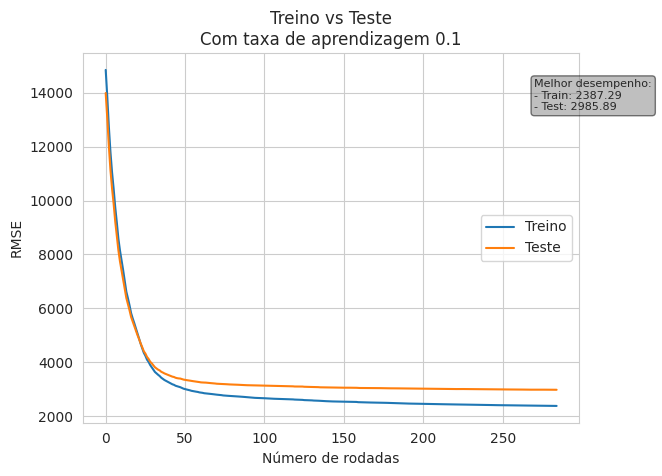

In [54]:
params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 0.6,
    'max_depth': 3,
    'subsample': 1.0,
    'eta': 0.1 ## Melhora a taxa de aprendizagem (melhor foi 0.3)
}

evals_result = {}

modelo = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    verbose_eval=100,
    evals_result=evals_result,
    early_stopping_rounds=10
)

train_mse = evals_result['train']['rmse']
test_mse = evals_result['test']['rmse']

grafico_taxa_aprendizagem(train_mse, test_mse, eta=params['eta'])

[0]	train-rmse:12440.54400	test-rmse:11752.11513
[100]	train-rmse:2435.54836	test-rmse:2971.38449
[181]	train-rmse:2335.08885	test-rmse:2922.04172


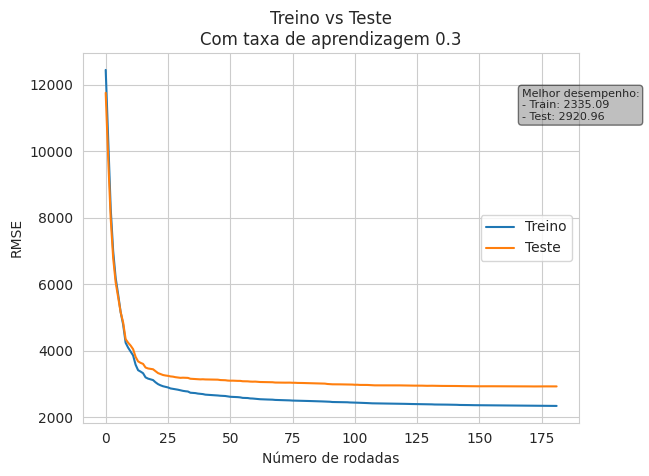

In [55]:
params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 0.6,
    'max_depth': 3,
    'subsample': 1.0,
    'eta': 0.3 ## Melhora a taxa de aprendizagem (melhor foi 0.3)
}

evals_result = {}

modelo = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    verbose_eval=100,
    evals_result=evals_result,
    early_stopping_rounds=10
)

train_mse = evals_result['train']['rmse']
test_mse = evals_result['test']['rmse']

grafico_taxa_aprendizagem(train_mse, test_mse, eta=params['eta'])

[0]	train-rmse:7372.44573	test-rmse:7387.18118
[62]	train-rmse:2452.13371	test-rmse:3054.31028


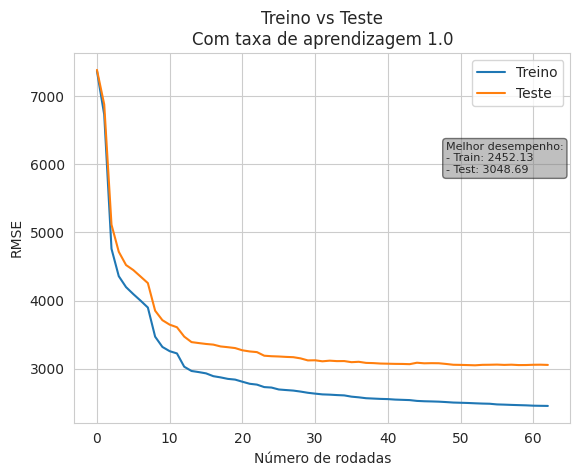

In [56]:
params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 0.6,
    'max_depth': 3,
    'subsample': 1.0,
    'eta': 1.0 ## Melhora a taxa de aprendizagem (melhor foi 0.3)
}

evals_result = {}

modelo = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    verbose_eval=100,
    evals_result=evals_result,
    early_stopping_rounds=10
)

train_mse = evals_result['train']['rmse']
test_mse = evals_result['test']['rmse']

grafico_taxa_aprendizagem(train_mse, test_mse, eta=params['eta'])

## **Melhor Configuração**

[0]	train-rmse:12440.54400	test-rmse:11752.11513
[100]	train-rmse:2435.54836	test-rmse:2971.38449
[181]	train-rmse:2335.08885	test-rmse:2922.04172


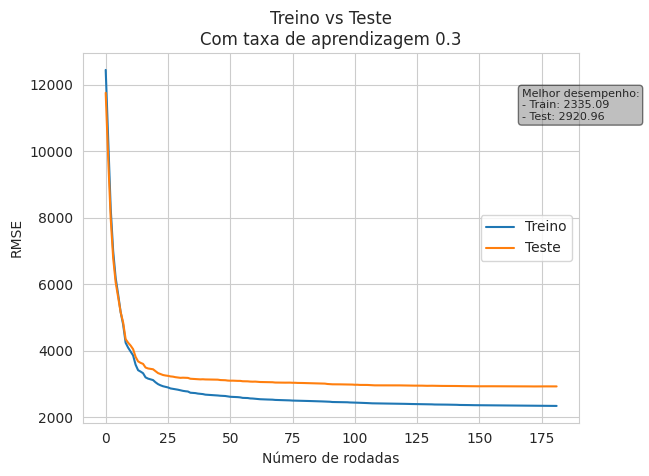

In [57]:
params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 0.6,
    'max_depth': 3,
    'subsample': 1.0,
    'eta': 0.3      ## Melhora a taxa de aprendizagem (melhor foi 0.3)
}

evals_result = {}

modelo = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    verbose_eval=100,
    evals_result=evals_result,
    early_stopping_rounds=10
)

train_mse = evals_result['train']['rmse']
test_mse = evals_result['test']['rmse']

grafico_taxa_aprendizagem(train_mse, test_mse, eta=params['eta'])

In [58]:
## Modelo Final

params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 0.6,
    'max_depth': 3,
    'subsample': 1,
    'eta': 0.3      ## Melhora a taxa de aprendizagem (melhor foi 0.3)
}

modelo_final = xgb.train(
    params = params,
    dtrain = dtrain,
    num_boost_round = 200
)

preds_final = modelo_final.predict(dtest)

In [59]:
preds_final

array([19404.455, 29096.242, 66011.95 , ..., 48178.203, 51759.785,
       32609.559], dtype=float32)

In [60]:
dtest.get_label()

array([20035., 29145., 60450., ..., 45750., 50360., 32715.], dtype=float32)

In [61]:
y_test.to_numpy()

array([20035, 29145, 60450, ..., 45750, 50360, 32715])

In [62]:
## Avaliacao Final
mae_final, mse_final, rmse_final, r2_final = get_metrics(dtest.get_label(), preds_final)

print(f'MAE: {get_format(mae_final)} (dólares "$")')
print(f'MSE: {get_format(mse_final)} (dólares "$")')
print(f'RMSE: {get_format(rmse_final)} (dólares "$")')
print(f'R2: {r2_final:.4f}')


MAE: 2.077,42 (dólares "$")
MSE: 8.564.092,00 (dólares "$")
RMSE: 2.926,45 (dólares "$")
R2: 0.9627


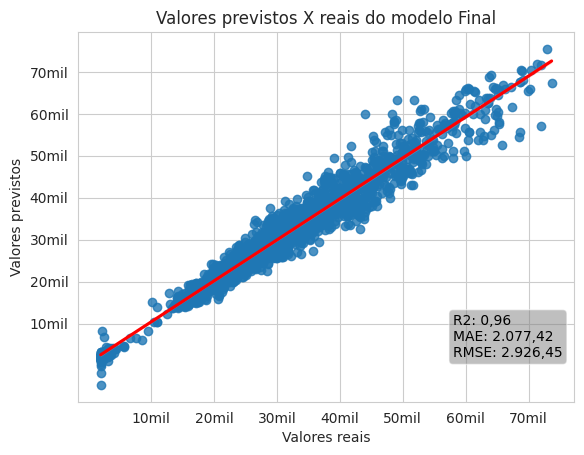

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(x=dtest.get_label(), y=preds_final, line_kws={'color':'red'})
plt.xlabel('Valores reais')
plt.ylabel('Valores previstos')
plt.title('Valores previstos X reais do modelo Final')

tick_locations = [x for x in range(int(10e3), int(80e3), int(10e3))]
tick_labels = [f'{x // 1000}mil' for x in tick_locations]
plt.xticks(tick_locations, tick_labels)
plt.yticks(tick_locations, tick_labels)
plt.text(58000, 2000, s=f'R2: {get_format(r2_final)}\nMAE: {get_format(mae_final)}\nRMSE: {get_format(rmse_final)}', color='black',
         bbox=dict(facecolor='gray', alpha=0.5, boxstyle='round'))
plt.show()

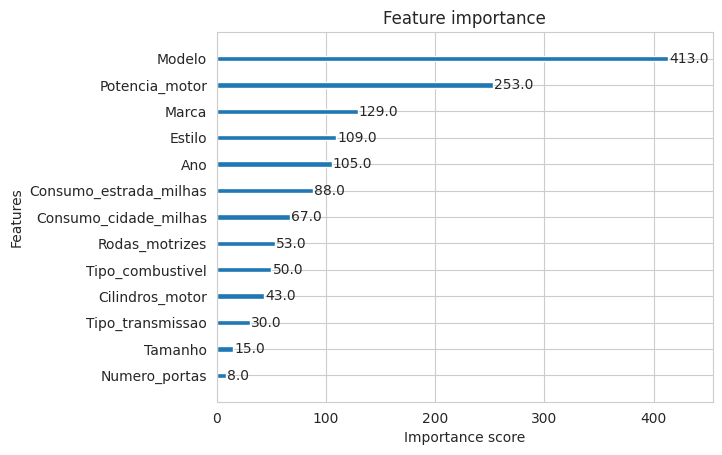

In [64]:
# Features mais importantes do modelo final
xgb.plot_importance(modelo_final)
plt.show()

### **Análise do SHAP Summary Plot**
Neste gráfico, cada ponto é um veículo do conjunto de teste:
- **Eixo X (SHAP Value):** Se for positivo, a feature aumentou o preço previsto. Se negativo, diminuiu.
- **Cor:** Vermelho indica valores altos da feature, azul indica valores baixos.

Por exemplo, se a 'Potencia_motor' estiver vermelha à direita, significa que motores mais potentes elevam consideravelmente o valor do automóvel.

In [65]:
!pip install shap -q

/tmp/ipykernel_53140/3619268231.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="dot")


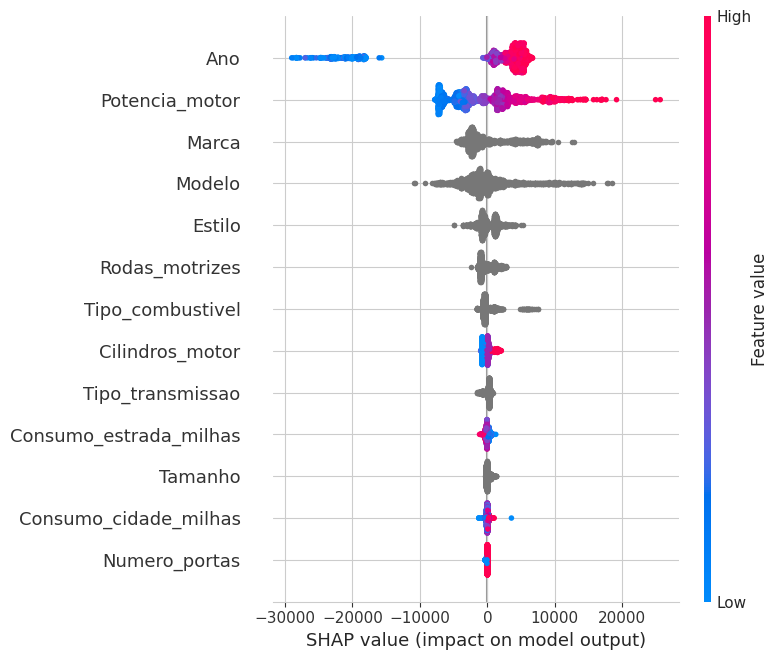

In [66]:
import shap

# Inicializa o explicador SHAP para o modelo XGBoost
explainer = shap.TreeExplainer(modelo_final)
# Calcula os SHAP values para o conjunto de teste
shap_values = explainer.shap_values(dtest)

# Visualização 1: Summary Plot (Impacto e distribuição)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot")

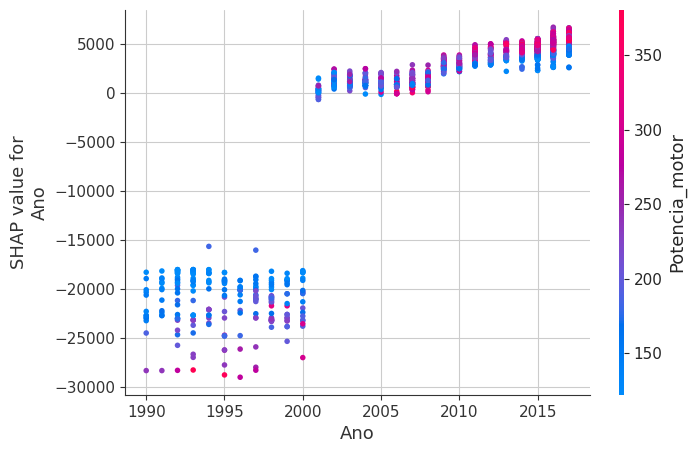

In [67]:
# Visualização 2: Dependence Plot para 'Ano'
# O SHAP escolhe automaticamente a variável de interação que mais explica a variação
shap.dependence_plot("Ano", shap_values, X_test)

### **Validação Cruzada**

In [68]:
## Validação Cruzada Final
params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 0.6,
    'max_depth': 3,
    'subsample': 1,
    'learning_rate': 0.3      ## Melhora a taxa de aprendizagem (melhor foi 0.3)
}

cv_resultados_final = xgb.cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=500,
    nfold=5,
    metrics='rmse',
    early_stopping_rounds=10,
    as_pandas=True,
    verbose_eval=50
)

[0]	train-rmse:12435.76662+11.47580	test-rmse:12467.69543+63.88276
[50]	train-rmse:2589.44800+26.35278	test-rmse:3065.57880+83.22677
[100]	train-rmse:2403.51413+23.61024	test-rmse:2968.06043+64.47621
[150]	train-rmse:2308.97224+20.79272	test-rmse:2945.56876+53.78274
[174]	train-rmse:2285.07625+18.56403	test-rmse:2943.72536+53.61675


In [69]:
cv_resultados_final

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,12435.766620,11.475801,12467.695426,63.882755
1,10283.161062,84.590747,10333.538637,95.277942
2,8180.421818,93.628958,8307.290816,127.250689
3,6907.591423,92.642221,7061.770002,133.799250
4,6088.532062,90.850012,6254.969100,108.543906
...,...,...,...,...
160,2297.925229,18.961194,2941.906715,53.382704
161,2296.843215,19.592549,2942.907289,54.113342
162,2296.176856,19.633479,2942.299608,53.999733
163,2295.701033,19.686052,2941.748519,53.693696


In [70]:
print("Resultados da Validação Cruzada".center(60))
print('==='*20)
print(f'Treino: ${cv_resultados_final['train-rmse-mean'].min():.2f}')
print(f'Treino (std): {cv_resultados_final['train-rmse-std'].min():.2f}')
print('---'*20)
print(f'Teste: ${cv_resultados_final['test-rmse-mean'].min():.2f}')
print(f'Teste (std): {cv_resultados_final['test-rmse-std'].min():.2f}')
print('==='*20)

              Resultados da Validação Cruzada               
Treino: $2294.69
Treino (std): 11.48
------------------------------------------------------------
Teste: $2941.53
Teste (std): 53.26


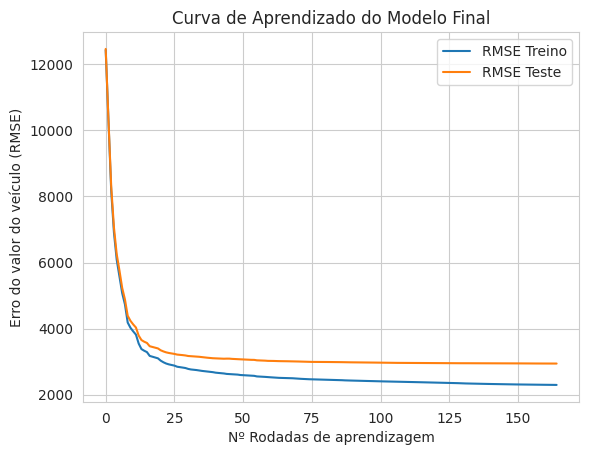

In [71]:
iteracoes = range(len(cv_resultados_final))

plt.plot(iteracoes, cv_resultados_final['train-rmse-mean'], label='RMSE Treino')
plt.plot(iteracoes, cv_resultados_final['test-rmse-mean'], label='RMSE Teste')
plt.title('Curva de Aprendizado do Modelo Final')
plt.xlabel('Nº Rodadas de aprendizagem')
plt.ylabel('Erro do valor do veículo (RMSE)')
plt.legend()
plt.show()

# **Salvando Modelo Final**

### **Treinamento Final**

In [72]:
import xgboost as xgb
import pandas as pd

# 1. Junta as features (X) e os alvos (y) usando o Pandas
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

# 2. Cria o NOVO DMatrix unificado pronto para o modelo final
dmatrix_final = xgb.DMatrix(X_full, label=y_full)

In [73]:
params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 0.6,
    'max_depth': 3,
    'subsample': 1,
    'learning_rate': 0.3
}

# Treinando o modelo final com todos os dados
modelo_final = xgb.train(
    params=params,
    dtrain=dmatrix_final,
    num_boost_round=200
)

In [74]:
import joblib
import json

## Markdown com os paramtros do modelo
readme_xgboost = {
    'Modelo': 'XGBoost',
    'RMSE treino': 2941.53,
    'RMSE teste': 2294.69,
    'Desvio treino': 11.48,
    'Desvio teste': 53.26,

    'Melhores parametros': {
        'colsample_bytree': 0.6,
        'learning_rate': 0.3,
        'max_depth': 3,
        'objective': 'reg:squarederror',
        'subsample': 1
    }
}

## Salvando o modelo
joblib.dump(value=modelo_final, filename='modelo_regressor_xgboost_final.pkl')

## Salvando json do modelo
with open('readme_xgboost.json', 'w') as f:
    json.dump(readme_xgboost, f)

# **Prevendo novos valores**

In [154]:
X.head(2)

,Marca,Modelo,Ano,Tipo_combustivel,Potencia_motor,Cilindros_motor,Tipo_transmissao,Rodas_motrizes,Numero_portas,Tamanho,Estilo,Consumo_estrada_milhas,Consumo_cidade_milhas
0,GMC,Envoy XL,2005,gasolina comum,275.0,6.0,automatico,tracao traseira,4.0,grande,SUV 4 portas,18,13
1,Volkswagen,Passat,2016,gasolina comum,170.0,4.0,automatico,tracao dianteira,4.0,medio,seda,38,25


In [155]:
## Formata os preços
def get_format(num):
    return f'{num:,.2f}'.replace('.','X').replace(',','.').replace('X',',')

In [156]:
## Retorna as colunas categoricas no formato category
def modifca_categoria(df):
    # Garantindo que as colunas categóricas tenham o tipo correto
    colunas_cat = df.select_dtypes('object').columns
    df[colunas_cat] = df[colunas_cat].astype('category')

    return df

In [157]:
import joblib
import xgboost as xgb
import pandas as pd

# Carregando o modelo
modelo_final = joblib.load(filename='modelo_regressor_xgboost_final.pkl')

## Retorna a previsão do automovel
def previsa_preco(modelo, novos_dados):
    for col in novos_dados.select_dtypes(['category']).columns:
        novos_dados[col] = novos_dados[col].cat.set_categories(X_train[col].cat.categories)

    # Preparando os dados para o XGBoost Nativo
    dados_predict = xgb.DMatrix(novos_dados, enable_categorical=True)

    # Realizando a previsão
    resultado = modelo_final.predict(dados_predict)

    return resultado

In [158]:
## Função que retorna o valor formatado dos dados
def mostra_previsao_formatada(result_previsao, df_novos_dados):
    print(f'Resultado de precificação dos automovéis'.upper().center(60))
    print('==='*20)
    for i, r in enumerate(result_previsao):
        print(f'Automomóvel: {df_novos_dados["Marca"][i]}')
        print(f'Ano: {df_novos_dados["Ano"][i]}')
        print(f'Valor: ${get_format(r)}')
        if i < len(result_previsao) - 1:
            print('---'*20)
        else:
            print('==='*20)

In [159]:
## NOVO dado
novos_dados = pd.DataFrame({
    'Marca': ['Honda'],
    'Modelo': ['Civic'],
    'Ano': [2009],
    'Tipo_combustivel': ['gasolina comum'],
    'Potencia_motor': [190.0],
    'Cilindros_motor': [4.0],
    'Tipo_transmissao': ['automatico'],
    'Rodas_motrizes': ['tracao dianteira'],
    'Numero_portas': [4.0],
    'Tamanho': ['medio'],
    'Estilo': ['seda'],
    'Consumo_estrada_milhas': [14],
    'Consumo_cidade_milhas': [10]
})

novos_dados = modifca_categoria(novos_dados)

In [160]:
## Previsão de um carro
novos_dados = modifca_categoria(novos_dados) # Faz a modificaçao (category)
previsao = previsa_preco(modelo_final, novos_dados) # Retorna a previsão do valor do automovel
mostra_previsao_formatada(previsao, novos_dados) # Formata e traz o valor e o automovel

          RESULTADO DE PRECIFICAÇÃO DOS AUTOMOVÉIS          
Automomóvel: Honda
Ano: 2009
Valor: $23.398,12


In [161]:
## Previsão de varios carros:
## Base da dados nova
path_novos_dados = 'https://raw.githubusercontent.com/alura-cursos/regressao_boosting/refs/heads/main/Dados/novos_automoveis.csv'
df_novos_dados = pd.read_csv(path_novos_dados)


df_novos_dados_modificado = modifca_categoria(df_novos_dados) # Faz a modificaçao (category)
previsoes = previsa_preco(modelo_final, df_novos_dados_modificado) # Retorna a previsão do valor do automovel
mostra_previsao_formatada(previsoes, df_novos_dados_modificado) # Formata e traz o valor e o automovel

          RESULTADO DE PRECIFICAÇÃO DOS AUTOMOVÉIS          
Automomóvel: Subaru
Ano: 2013
Valor: $35.376,69
------------------------------------------------------------
Automomóvel: Honda
Ano: 2012
Valor: $19.532,07
------------------------------------------------------------
Automomóvel: Volvo
Ano: 2015
Valor: $47.144,47
------------------------------------------------------------
Automomóvel: Honda
Ano: 2016
Valor: $23.974,32


In [162]:
df_com_previsoes = df_novos_dados.copy()

In [171]:
df_com_previsoes['previsoes'] = previsoes_arredondads
df_com_previsoes

,Marca,Modelo,Ano,Tipo_combustivel,Potencia_motor,Cilindros_motor,Tipo_transmissao,Rodas_motrizes,Numero_portas,Tamanho,Estilo,Consumo_estrada_milhas,Consumo_cidade_milhas,previsoes
0,Subaru,Impreza WRX,2013,gasolina premium (obrigatoria),305.0,4.0,manual,tracao integral,4.0,compacto,seda,22,15,35376.699219
1,Honda,NaN,2012,gasolina comum,98.0,4.0,automatico,tracao dianteira,4.0,compacto,hatchback 4 portas,49,38,19532.099609
2,Volvo,XC90,2015,gasolina premium (recomendada),250.0,4.0,automatico,tracao dianteira,4.0,grande,SUV 4 portas,25,20,47144.500000
3,Honda,HR-V,2016,gasolina comum,141.0,4.0,automatico,tracao integral,4.0,compacto,SUV 4 portas,32,28,23974.300781
